**Домашнее задание 6.1: Распространение тепла в теле с переменной теплопроводностью**

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron, eye, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.integrate import trapezoid
import time

1). 1D случай

Параметры задачи:

In [62]:
L = 1.0  # длина стержня
k0 = 1.0  # базовая теплопроводность
t_end = 0.5  # конечное время
x_points_list = [51, 101, 151, 201]  # различные сетки для анализа сходимости

Аналитическое решение для постоянной теплопроводности (k = k0):

In [63]:
def analytical_solution_constant_k(x, t, k0, L, n_terms=100):
    u = np.ones_like(x)  # граничное условие u(0,t) = 1
    for n in range(1, n_terms + 1):
        lambda_n = (2 * n - 1) * np.pi / (2 * L)
        coeff = 2 / (lambda_n * L)
        u -= coeff * np.sin(lambda_n * x) * np.exp(-k0 * lambda_n**2 * t)
    return u

Функция переменной теплопроводности:

In [64]:
def k_func(x, k0):
    return np.full_like(x, k0) # для сравнения с анатилическим, убрать если хотим изучить переменную теплопроводность
    return k0 * (1 + 0.5 * np.sin(2 * np.pi * x))

Явная схема FTCS (с учетом CFL условия):

In [65]:
def ftcs_solver(Nx, t, L, k0):
    dx = L / (Nx - 1)
    x = np.linspace(0, L, Nx)
    k = k_func(x, k0)
    max_k = np.max(k)
    dt_stable = 0.5 * dx**2 / max_k      # Автоматический подбор шага по времени для устойчивости (CFL ≤ 0.5)
    Nt = max(1, int(t / dt_stable)) + 1
    dt_actual = t / Nt
    u = np.zeros(Nx)  # начальное условие u(x,0) = 0
    u[0] = 1.0  # граничное условие u(0,t) = 1
    alpha = dt_actual / dx**2 # Коэффициент для FTCS схемы
    for n in range(Nt):
        u_new = u.copy()
        for i in range(1, Nx - 1):
            k_plus = 0.5 * (k[i] + k[i + 1])
            k_minus = 0.5 * (k[i] + k[i - 1])
            flux_plus = k_plus * (u[i + 1] - u[i])
            flux_minus = k_minus * (u[i] - u[i - 1])
            u_new[i] = u[i] + alpha * (flux_plus - flux_minus)
        u_new[0] = 1.0  # u(0,t) = 1
        u_new[-1] = u_new[-2]  # нулевой поток на правой границе (условие Неймана)
        u = u_new
    return x, u

Схема Кранка-Никольсона

In [66]:
def crank_nicolson_solver(Nx, t, L, k0):
    dx = L / (Nx - 1)
    dt = min(0.01, t/10)  # Для неявной схемы можно использовать больший шаг по времени
    Nt = max(1, int(t / dt))
    dt_actual = t / Nt
    x = np.linspace(0, L, Nx)
    u = np.zeros(Nx)  # начальное условие
    u[0] = 1.0  # граничное условие
    k = k_func(x, k0)
    alpha = dt_actual / (2 * dx**2) # Коэффициенты для матричной системы
    main_diag = np.ones(Nx)
    upper_diag = np.zeros(Nx - 1)
    lower_diag = np.zeros(Nx - 1)
    for i in range(1, Nx - 1):
        k_plus = 0.5 * (k[i] + k[i + 1])
        k_minus = 0.5 * (k[i] + k[i - 1])
        main_diag[i] = 1 + alpha * (k_plus + k_minus)
        upper_diag[i] = -alpha * k_plus
        lower_diag[i - 1] = -alpha * k_minus
    # Граничные условия
    main_diag[0] = 1.0
    upper_diag[0] = 0.0
    main_diag[-1] = 1.0
    lower_diag[-1] = -1.0  # для условия Неймана
    A = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], format='csc')
    for n in range(Nt):
        b = u.copy()
        for i in range(1, Nx - 1):
            k_plus = 0.5 * (k[i] + k[i + 1])
            k_minus = 0.5 * (k[i] + k[i - 1])
            flux_plus = k_plus * (u[i + 1] - u[i])
            flux_minus = k_minus * (u[i] - u[i - 1])
            b[i] = u[i] + alpha * (flux_plus - flux_minus)
        # Граничные условия в правой части
        b[0] = 1.0
        b[-1] = 0.0  # для условия Неймана
        u = spsolve(A, b) 
    return x, u

Расчет тепловой энергии:

In [67]:
def calculate_thermal_energy(u, dx):
    return trapezoid(u, dx=dx)

Анализ сходимости

In [68]:
def convergence_analysis():
    errors_ftcs = []
    errors_cn = []
    dx_values = []
    t_test = 0.1  
    Nx_fine = 501
    x_fine, u_fine = crank_nicolson_solver(Nx_fine, t_test, L, k0)
    for Nx in x_points_list:
        dx = L / (Nx - 1)
        x_ftcs, u_ftcs = ftcs_solver(Nx, t_test, L, k0)
        x_cn, u_cn = crank_nicolson_solver(Nx, t_test, L, k0)
        u_fine_on_ftcs = np.interp(x_ftcs, x_fine, u_fine)
        u_fine_on_cn = np.interp(x_cn, x_fine, u_fine)
        error_ftcs = np.sqrt(dx * np.sum((u_ftcs - u_fine_on_ftcs)**2))
        error_cn = np.sqrt(dx * np.sum((u_cn - u_fine_on_cn)**2))
        errors_ftcs.append(error_ftcs)
        errors_cn.append(error_cn)
        dx_values.append(dx)
    return dx_values, errors_ftcs, errors_cn

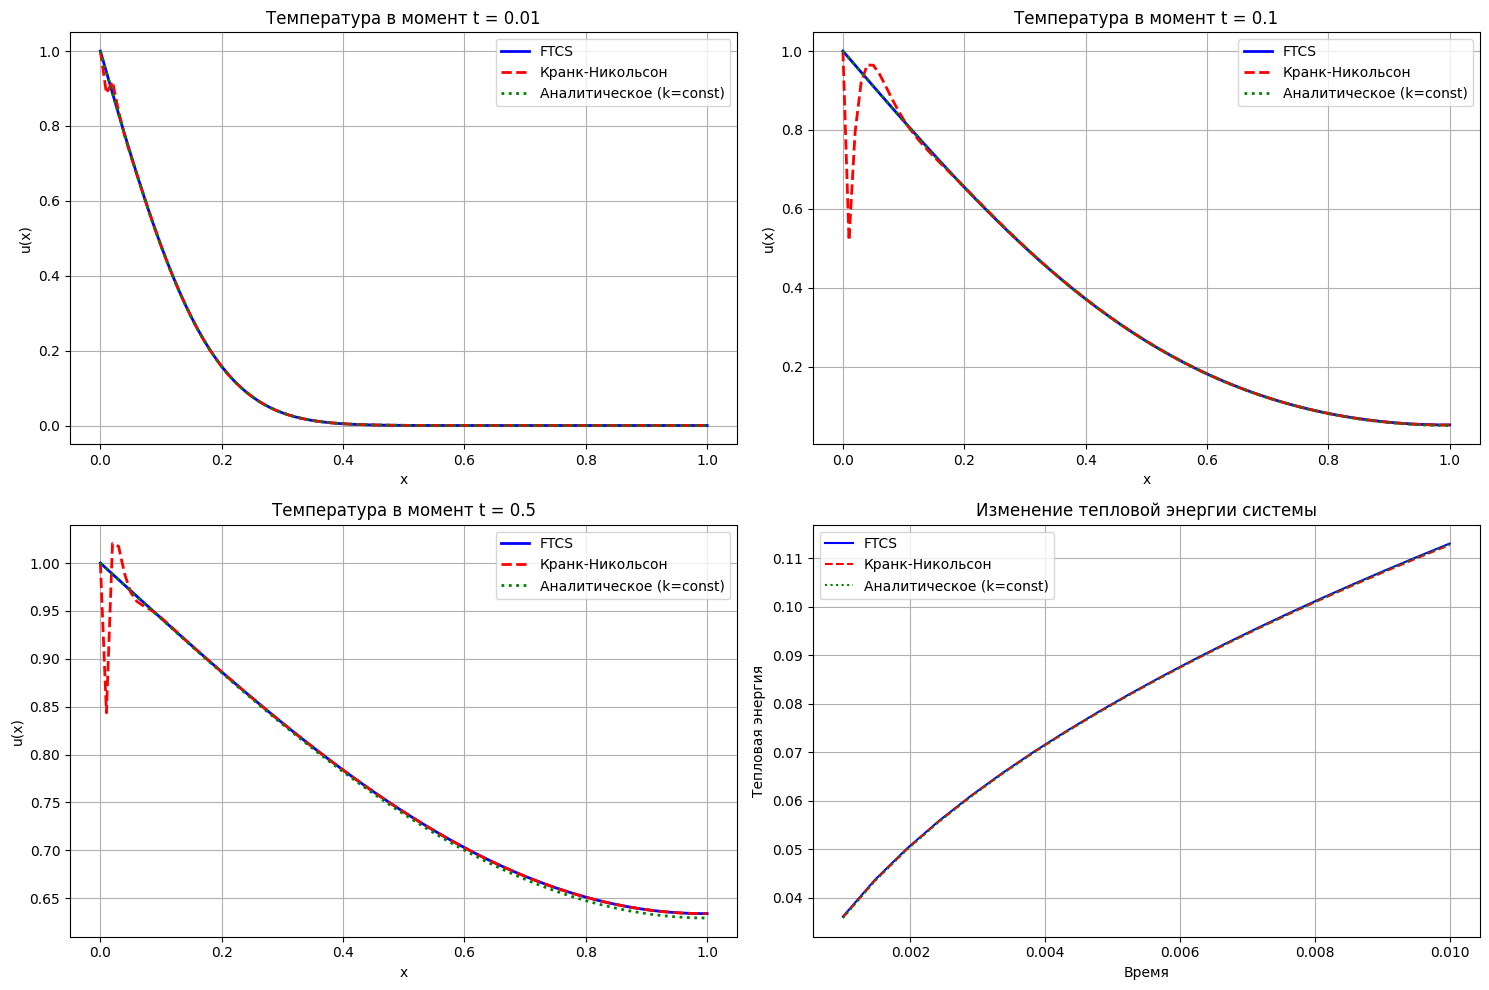

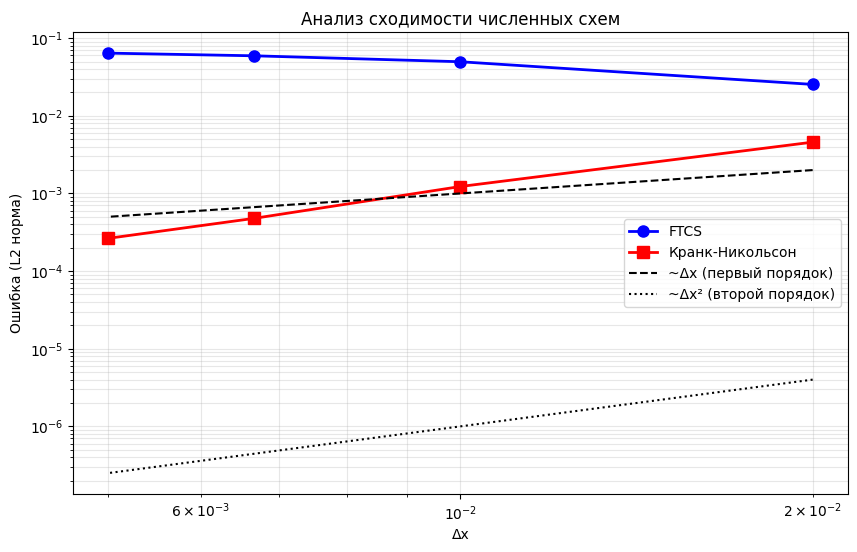

In [69]:
Nx = 101
time_points = [0.01, 0.1, 0.5]
    
plt.figure(figsize=(15, 10))
for i, t in enumerate(time_points):
    x_ftcs, u_ftcs = ftcs_solver(Nx, t, L, k0)
    x_cn, u_cn = crank_nicolson_solver(Nx, t, L, k0)
    u_analytical = analytical_solution_constant_k(x_ftcs, t, k0, L)
    plt.subplot(2, 2, i + 1)
    plt.plot(x_ftcs, u_ftcs, 'b-', linewidth=2, label='FTCS')
    plt.plot(x_cn, u_cn, 'r--', linewidth=2, label='Кранк-Никольсон')
    plt.plot(x_ftcs, u_analytical, 'g:', linewidth=2, label='Аналитическое (k=const)')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title(f'Температура в момент t = {t}')
    plt.legend()
    plt.grid(True)
    
plt.subplot(2, 2, 4)
        
time_array = np.linspace(0.001, 0.01, 20)  
energy_ftcs = []
energy_cn = []
energy_analytical = []
for j, t in enumerate(time_array):
    x_ftcs, u_ftcs = ftcs_solver(Nx, t, L, k0)
    x_cn, u_cn = crank_nicolson_solver(Nx, t, L, k0)
    u_analytical = analytical_solution_constant_k(x_ftcs, t, k0, L)
    dx = L / (Nx - 1)
    energy_ftcs.append(calculate_thermal_energy(u_ftcs, dx))
    energy_cn.append(calculate_thermal_energy(u_cn, dx))
    energy_analytical.append(calculate_thermal_energy(u_analytical, dx))
    
plt.plot(time_array, energy_ftcs, 'b-', label='FTCS')
plt.plot(time_array, energy_cn, 'r--', label='Кранк-Никольсон')
plt.plot(time_array, energy_analytical, 'g:', label='Аналитическое (k=const)')
plt.xlabel('Время')
plt.ylabel('Тепловая энергия')
plt.title('Изменение тепловой энергии системы')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
    
dx_values, errors_ftcs, errors_cn = convergence_analysis()
plt.figure(figsize=(10, 6))
plt.loglog(dx_values, errors_ftcs, 'bo-', linewidth=2, markersize=8, label='FTCS')
plt.loglog(dx_values, errors_cn, 'rs-', linewidth=2, markersize=8, label='Кранк-Никольсон')    
dx_theory = np.array(dx_values)
plt.loglog(dx_theory, 0.1 * dx_theory, 'k--', label='~Δx (первый порядок)')
plt.loglog(dx_theory, 0.01 * dx_theory**2, 'k:', label='~Δx² (второй порядок)')
plt.xlabel('Δx')
plt.ylabel('Ошибка (L2 норма)')
plt.title('Анализ сходимости численных схем')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

2). 2D случай

Рассмотрим прямоугольную пластину с произвольными функциями k(x,y).

Возьмем синусоидальное распределение теплопроводности.

In [70]:
def k_sinusoidal(x, y, k0=1.0, amplitude=0.5, freq_x=2, freq_y=2):
    return k0 * (1 + amplitude * np.sin(freq_x * np.pi * x) * np.cos(freq_y * np.pi * y))

Явная схема FTCS для 2D

In [ ]:
def ftcs_2d_solver(Nx, Ny, t_end, k_func, source_temp, Lx=1.0, Ly=1.0):
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y)
    k = k_func(X, Y)
    max_k = np.max(k)
    dt_stable = 0.25 * min(dx**2, dy**2) / max_k
    Nt = max(1, int(t_end / dt_stable))
    dt = t_end / Nt

    u_initial = np.zeros((Ny, Nx))
    center_i, center_j = Ny // 2, Nx // 2
    u_initial[center_i, center_j] = source_temp
    u = u_initial.copy()
    
    # Предвычисляем коэффициенты теплопроводности на гранях (векторно)
    k_x_plus = 0.5 * (k[:, :-1] + k[:, 1:])   # форма (Ny, Nx-1)
    k_x_minus = 0.5 * (k[:, :-1] + k[:, 1:])  # форма (Ny, Nx-1)
    k_y_plus = 0.5 * (k[:-1, :] + k[1:, :])   # форма (Ny-1, Nx)
    k_y_minus = 0.5 * (k[:-1, :] + k[1:, :])  # форма (Ny-1, Nx)
    
    alpha_x = dt / dx**2
    alpha_y = dt / dy**2
    
    for n in range(Nt):
        # Векторное вычисление потоков по x (для внутренних точек)
        flux_x_plus = k_x_plus[1:-1, 1:] * (u[1:-1, 2:] - u[1:-1, 1:-1])     # i, j+1/2
        flux_x_minus = k_x_minus[1:-1, :-1] * (u[1:-1, 1:-1] - u[1:-1, :-2]) # i, j-1/2
        
        # Векторное вычисление потоков по y (для внутренних точек)
        flux_y_plus = k_y_plus[1:, 1:-1] * (u[2:, 1:-1] - u[1:-1, 1:-1])     # i+1/2, j
        flux_y_minus = k_y_minus[:-1, 1:-1] * (u[1:-1, 1:-1] - u[:-2, 1:-1]) # i-1/2, j
        
        # Обновление всех внутренних точек сразу
        u_new = u.copy()
        u_new[1:-1, 1:-1] = u[1:-1, 1:-1] + alpha_x * (flux_x_plus - flux_x_minus) + alpha_y * (flux_y_plus - flux_y_minus)
        
        # Граничные условия (векторно)
        u_new[0, :] = 0.0
        u_new[-1, :] = 0.0
        u_new[:, 0] = 0.0
        u_new[:, -1] = 0.0
        
        # Источник тепла
        u_new[center_i, center_j] = source_temp
        
        u = u_new
    return X, Y, u_initial, u, k, dt, Nt

In [ ]:
def ftcs_2d_solver_old(Nx, Ny, t_end, k_func, source_temp, Lx=1.0, Ly=1.0):
    """Старая, векторно-неоптимизированная схема"""
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y)
    k = k_func(X, Y)
    max_k = np.max(k)
    dt_stable = 0.25 * min(dx**2, dy**2) / max_k
    Nt = max(1, int(t_end / dt_stable))
    dt = t_end / Nt

    u_initial = np.zeros((Ny, Nx))
    center_i, center_j = Ny // 2, Nx // 2
    u_initial[center_i, center_j] = source_temp
    u = u_initial.copy()
    
    for n in range(Nt):
        u_new = u.copy()
        u_new[center_i, center_j] = source_temp
        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                if i == center_i and j == center_j:
                    continue
                k_x_plus = 0.5 * (k[i, j] + k[i, j + 1])
                k_x_minus = 0.5 * (k[i, j] + k[i, j - 1])
                k_y_plus = 0.5 * (k[i, j] + k[i + 1, j])
                k_y_minus = 0.5 * (k[i, j] + k[i - 1, j])
                flux_x = (k_x_plus * (u[i, j + 1] - u[i, j]) - k_x_minus * (u[i, j] - u[i, j - 1])) / dx**2
                flux_y = (k_y_plus * (u[i + 1, j] - u[i, j]) - k_y_minus * (u[i, j] - u[i - 1, j])) / dy**2
                u_new[i, j] = u[i, j] + dt * (flux_x + flux_y)
        u_new[0, :] = 0.0
        u_new[-1, :] = 0.0
        u_new[:, 0] = 0.0
        u_new[:, -1] = 0.0
        u = u_new
    return X, Y, u_initial, u, k, dt, Nt

Кранк-Никольсон для 2D

In [86]:
def crank_nicolson_2d_solver(Nx, Ny, t_end, k_func, source_temp, Lx=1.0, Ly=1.0, dt=0.01):
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y)
    k = k_func(X, Y)
    Nt = max(1, int(t_end / dt))
    dt_actual = t_end / Nt
    
    u_initial = np.zeros((Ny, Nx))
    center_i, center_j = Ny // 2, Nx // 2
    u = u_initial.copy()
    
    alpha = dt_actual / 2
    alpha_x = alpha / dx**2
    alpha_y = alpha / dy**2
    
    # Предвычисляем коэффициенты теплопроводности на гранях
    k_x_plus = 0.5 * (k[:, :-1] + k[:, 1:])   # форма (Ny, Nx-1)
    k_x_minus = k_x_plus  # симметрично
    k_y_plus = 0.5 * (k[:-1, :] + k[1:, :])   # форма (Ny-1, Nx)
    k_y_minus = k_y_plus  # симметрично
    
    for n in range(Nt):
        # ===== Первый полушаг: неявно по x, явно по y =====
        u_half = u.copy()
        
        for i in range(1, Ny - 1):
            # Векторное построение трёхдиагональной матрицы для строки i
            main_diag = np.ones(Nx)
            upper_diag = np.zeros(Nx - 1)
            lower_diag = np.zeros(Nx - 1)
            b = np.zeros(Nx)
            
            # Векторное вычисление коэффициентов для внутренних точек
            j_range = np.arange(1, Nx - 1)
            main_diag[j_range] = 1 + alpha_x * (k_x_plus[i, j_range] + k_x_minus[i, j_range - 1])
            upper_diag[j_range] = -alpha_x * k_x_plus[i, j_range]
            lower_diag[j_range - 1] = -alpha_x * k_x_minus[i, j_range - 1]
            
            # Векторное вычисление правой части (явный поток по y)
            flux_y_plus = k_y_plus[i, j_range] * (u[i + 1, j_range] - u[i, j_range])
            flux_y_minus = k_y_minus[i - 1, j_range] * (u[i, j_range] - u[i - 1, j_range])
            b[j_range] = u[i, j_range] + alpha_y * (flux_y_plus - flux_y_minus)
            
            # Граничные условия
            main_diag[0] = 1.0
            upper_diag[0] = 0.0
            b[0] = 0.0
            main_diag[-1] = 1.0
            lower_diag[-1] = 0.0
            b[-1] = 0.0
            
            # Источник тепла
            if i == center_i:
                main_diag[center_j] = 1.0
                if center_j > 0:
                    lower_diag[center_j - 1] = 0.0
                if center_j < Nx - 1:
                    upper_diag[center_j] = 0.0
                b[center_j] = source_temp
            
            A = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], format='csc')
            u_half[i, :] = spsolve(A, b)
        
        # ===== Второй полушаг: неявно по y, явно по x =====
        u_new = u_half.copy()
        
        for j in range(1, Nx - 1):
            # Векторное построение трёхдиагональной матрицы для столбца j
            main_diag = np.ones(Ny)
            upper_diag = np.zeros(Ny - 1)
            lower_diag = np.zeros(Ny - 1)
            b = np.zeros(Ny)
            
            # Векторное вычисление коэффициентов для внутренних точек
            i_range = np.arange(1, Ny - 1)
            main_diag[i_range] = 1 + alpha_y * (k_y_plus[i_range, j] + k_y_minus[i_range - 1, j])
            upper_diag[i_range] = -alpha_y * k_y_plus[i_range, j]
            lower_diag[i_range - 1] = -alpha_y * k_y_minus[i_range - 1, j]
            
            # Векторное вычисление правой части (явный поток по x)
            flux_x_plus = k_x_plus[i_range, j] * (u_half[i_range, j + 1] - u_half[i_range, j])
            flux_x_minus = k_x_minus[i_range, j - 1] * (u_half[i_range, j] - u_half[i_range, j - 1])
            b[i_range] = u_half[i_range, j] + alpha_x * (flux_x_plus - flux_x_minus)
            
            # Граничные условия
            main_diag[0] = 1.0
            upper_diag[0] = 0.0
            b[0] = 0.0
            main_diag[-1] = 1.0
            lower_diag[-1] = 0.0
            b[-1] = 0.0
            
            # Источник тепла
            if j == center_j:
                main_diag[center_i] = 1.0
                if center_i > 0:
                    lower_diag[center_i - 1] = 0.0
                if center_i < Ny - 1:
                    upper_diag[center_i] = 0.0
                b[center_i] = source_temp
            
            A = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], format='csc')
            u_new[:, j] = spsolve(A, b)
        
        # Применяем граничные условия векторно
        u_new[0, :] = 0.0
        u_new[-1, :] = 0.0
        u_new[:, 0] = 0.0
        u_new[:, -1] = 0.0
        u_new[center_i, center_j] = source_temp
        u = u_new
    
    return X, Y, u_initial, u, k, dt_actual, Nt


In [85]:
def crank_nicolson_2d_solver_old(Nx, Ny, t_end, k_func, source_temp, Lx=1.0, Ly=1.0, dt=0.01):
    """Старая, векторно-неоптимизированная схема"""
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y)
    k = k_func(X, Y)
    Nt = max(1, int(t_end / dt))
    dt_actual = t_end / Nt
    
    u_initial = np.zeros((Ny, Nx))
    center_i, center_j = Ny // 2, Nx // 2
    u = u_initial.copy()
    
    alpha = dt_actual / 2
    for n in range(Nt):
        u_half = u.copy()
        for i in range(1, Ny - 1):
            main_diag = np.ones(Nx)
            upper_diag = np.zeros(Nx - 1)
            lower_diag = np.zeros(Nx - 1)
            b = np.zeros(Nx)
            for j in range(1, Nx - 1):
                if i == center_i and j == center_j:
                    main_diag[j] = 1.0
                    upper_diag[j] = 0.0
                    lower_diag[j - 1] = 0.0
                    b[j] = source_temp 
                    continue
                k_x_plus = 0.5 * (k[i, j] + k[i, j + 1])
                k_x_minus = 0.5 * (k[i, j] + k[i, j - 1])
                k_y_plus = 0.5 * (k[i, j] + k[i + 1, j])
                k_y_minus = 0.5 * (k[i, j] + k[i - 1, j])
                main_diag[j] = 1 + (alpha / dx**2) * (k_x_plus + k_x_minus)
                upper_diag[j] = -(alpha / dx**2) * k_x_plus
                lower_diag[j - 1] = -(alpha / dx**2) * k_x_minus
                flux_y = (k_y_plus * (u[i + 1, j] - u[i, j]) - k_y_minus * (u[i, j] - u[i - 1, j])) / dy**2
                b[j] = u[i, j] + alpha * flux_y
    
            main_diag[0] = 1.0
            upper_diag[0] = 0.0
            b[0] = 0.0
            main_diag[-1] = 1.0
            lower_diag[-1] = 0.0
            b[-1] = 0.0
            A = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], format='csc')
            u_half[i, :] = spsolve(A, b)
        u_new = u_half.copy()
        
        for j in range(1, Nx - 1):
            main_diag = np.ones(Ny)
            upper_diag = np.zeros(Ny - 1)
            lower_diag = np.zeros(Ny - 1)
            b = np.zeros(Ny)
            for i in range(1, Ny - 1):
                if i == center_i and j == center_j:
                    main_diag[i] = 1.0
                    upper_diag[i] = 0.0
                    lower_diag[i - 1] = 0.0
                    b[i] = source_temp 
                    continue
                k_x_plus = 0.5 * (k[i, j] + k[i, j + 1])
                k_x_minus = 0.5 * (k[i, j] + k[i, j - 1])
                k_y_plus = 0.5 * (k[i, j] + k[i + 1, j])
                k_y_minus = 0.5 * (k[i, j] + k[i - 1, j])
                main_diag[i] = 1 + (alpha / dy**2) * (k_y_plus + k_y_minus)
                upper_diag[i] = -(alpha / dy**2) * k_y_plus
                lower_diag[i - 1] = -(alpha / dy**2) * k_y_minus
                flux_x = (k_x_plus * (u_half[i, j + 1] - u_half[i, j]) - k_x_minus * (u_half[i, j] - u_half[i, j - 1])) / dx**2
                b[i] = u_half[i, j] + alpha * flux_x
            
            main_diag[0] = 1.0
            upper_diag[0] = 0.0
            b[0] = 0.0
            main_diag[-1] = 1.0
            lower_diag[-1] = 0.0
            b[-1] = 0.0
            A = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], format='csc')
            u_new[:, j] = spsolve(A, b)

        u_new[0, :] = 0.0
        u_new[-1, :] = 0.0
        u_new[:, 0] = 0.0
        u_new[:, -1] = 0.0
        u_new[center_i, center_j] = source_temp
        u = u_new
    
    return X, Y, u_initial, u, k, dt_actual, Nt

Визуализация распределения теплопроводности

In [73]:
def plot_thermal_conductivity():
    Nx, Ny = 101, 101
    x = np.linspace(0, 1, Nx)
    y = np.linspace(0, 1, Ny)
    X, Y = np.meshgrid(x, y)
    
    k = k_sinusoidal(X, Y, amplitude=0.8, freq_x=3, freq_y=2)
    
    plt.figure(figsize=(12, 4))
    im = plt.imshow(k, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
    plt.title('Распределение теплопроводности\nk(x,y) = 1 + 0.8·sin(3πx)·cos(2πy)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

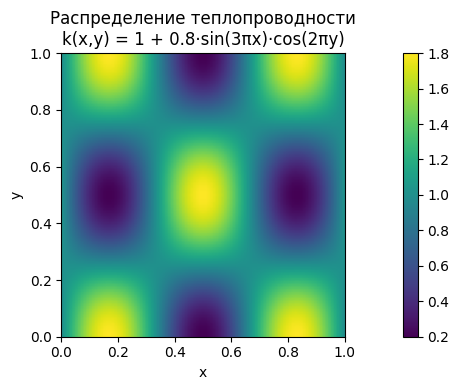

In [74]:
plot_thermal_conductivity()

Визуализация результатов

In [75]:
def plot_results_comparison():
    Nx, Ny = 61, 61
    t_end = 0.05 
    source_temp = 1000.0
    k_func = lambda x, y: k_sinusoidal(x, y, amplitude=0.8, freq_x=3, freq_y=2)
    
    X_ftcs, Y_ftcs, u_initial_ftcs, u_final_ftcs, k_ftcs, dt_ftcs, Nt_ftcs = ftcs_2d_solver(Nx, Ny, t_end, k_func, source_temp)
    X_cn, Y_cn, u_initial_cn, u_final_cn, k_cn, dt_cn, Nt_cn = crank_nicolson_2d_solver(Nx, Ny, t_end, k_func, source_temp, dt=0.005)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    vmin_temp, vmax_temp = 0.0, 1000.0
    
    # FTCS
    im1 = axes[0, 0].imshow(u_initial_ftcs, extent=[0, 1, 0, 1], origin='lower', cmap='hot', vmin=vmin_temp, vmax=vmax_temp)
    axes[0, 0].set_title('FTCS: Начальное условие\n(t = 0)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('y')
    axes[0, 0].plot(0.5, 0.5, 'wo', markersize=8, markeredgecolor='black')
    plt.colorbar(im1, ax=axes[0, 0])
    
    im2 = axes[0, 1].imshow(u_final_ftcs, extent=[0, 1, 0, 1], origin='lower', cmap='hot', vmin=vmin_temp, vmax=vmax_temp)
    axes[0, 1].set_title(f'FTCS: Конечное состояние\n(t = {t_end})', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('y')
    plt.colorbar(im2, ax=axes[0, 1])
    
    # КРАНК-НИКОЛЬСОН 
    im3 = axes[1, 0].imshow(u_initial_cn, extent=[0, 1, 0, 1], origin='lower', cmap='hot', vmin=vmin_temp, vmax=vmax_temp)
    axes[1, 0].set_title('Кранк-Никольсон: Начальное условие\n(t = 0)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')
    axes[1, 0].plot(0.5, 0.5, 'wo', markersize=8, markeredgecolor='black')
    plt.colorbar(im3, ax=axes[1, 0])
    
    im4 = axes[1, 1].imshow(u_final_cn, extent=[0, 1, 0, 1], origin='lower', cmap='hot', vmin=vmin_temp, vmax=vmax_temp)
    axes[1, 1].set_title(f'Кранк-Никольсон: Конечное состояние\n(t = {t_end})', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('y')
    plt.colorbar(im4, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()

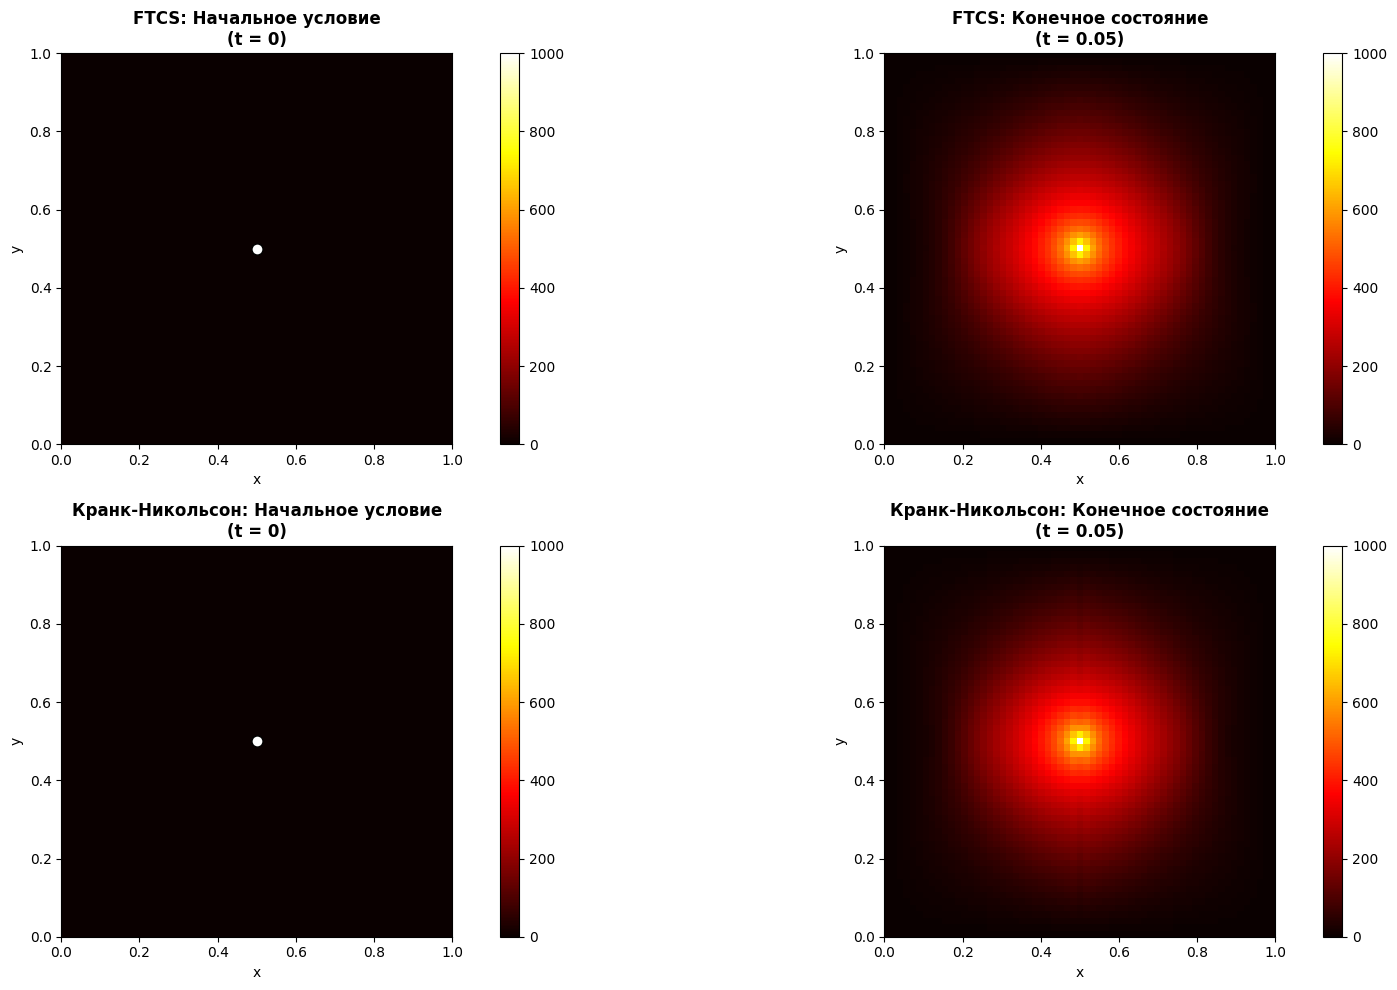

In [76]:
plot_results_comparison()

Сравним эффективность схем при разных шагах по времени:

In [ ]:
def compare_efficiency():
    Nx, Ny = 50, 50
    t_end = 0.1
    source_temp = 100.0
    
    def k_const(X, Y):
        return np.ones_like(X)

    dt_values = [0.01, 0.005, 0.001, 0.0005]
    ftcs_times = []
    cn_times = []
    ftcs_errors = [] 
    cn_errors = []
    
    # Референсное решение с мелким шагом
    _, _, _, u_ref, _, _, _ = crank_nicolson_2d_solver(Nx, Ny, t_end, k_const, source_temp, dt=0.0001)
    
    for dt in dt_values:
        print(f"\nТестирование dt = {dt}")
        
        start = time.time()
        _, _, _, u_ftcs, _, _, _ = ftcs_2d_solver(Nx, Ny, t_end, k_const, source_temp)
        ftcs_time = time.time() - start
        ftcs_error = np.linalg.norm(u_ftcs - u_ref) / np.linalg.norm(u_ref)
        ftcs_times.append(ftcs_time)
        ftcs_errors.append(ftcs_error)
        print(f"FTCS: {ftcs_time:.3f} сек, ошибка: {ftcs_error:.6f}")
        
        start = time.time()
        _, _, _, u_cn, _, _, _ = crank_nicolson_2d_solver(Nx, Ny, t_end, k_const, source_temp, dt=dt)
        cn_time = time.time() - start
        cn_error = np.linalg.norm(u_cn - u_ref) / np.linalg.norm(u_ref)
        cn_times.append(cn_time)
        cn_errors.append(cn_error)
        print(f"CN: {cn_time:.3f} сек, ошибка: {cn_error:.6f}")
    
    return dt_values, ftcs_times, cn_times, ftcs_errors, cn_errors

In [78]:
dt_vals, ftcs_t, cn_t, ftcs_e, cn_e = compare_efficiency()


Тестирование dt = 0.01
FTCS: 0.056 сек, ошибка: 0.000353
CN: 0.287 сек, ошибка: 0.022334

Тестирование dt = 0.005
FTCS: 0.067 сек, ошибка: 0.000353
CN: 0.628 сек, ошибка: 0.004153

Тестирование dt = 0.001
FTCS: 0.048 сек, ошибка: 0.000353
CN: 2.983 сек, ошибка: 0.000454

Тестирование dt = 0.0005
FTCS: 0.060 сек, ошибка: 0.000353
CN: 6.297 сек, ошибка: 0.000191


In [79]:
def plot_comparison(dt_values, ftcs_times, cn_times, ftcs_errors, cn_errors):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.semilogx(dt_values, cn_times, 'bo-', label='Crank-Nicolson', linewidth=2)
    ax1.semilogx(dt_values, ftcs_times, 'ro-', label='FTCS', linewidth=2)
    ax1.set_xlabel('Шаг по времени Δt')
    ax1.set_ylabel('Время выполнения (сек)')
    ax1.set_title('Сравнение времени выполнения')
    ax1.legend()
    ax1.grid(True)
    
    ax2.loglog(dt_values, cn_errors, 'bo-', label='Crank-Nicolson', linewidth=2)
    ax2.loglog(dt_values, ftcs_errors, 'ro-', label='FTCS', linewidth=2)
    ax2.set_xlabel('Шаг по времени Δt')
    ax2.set_ylabel('Относительная ошибка')
    ax2.set_title('Сравнение точности')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

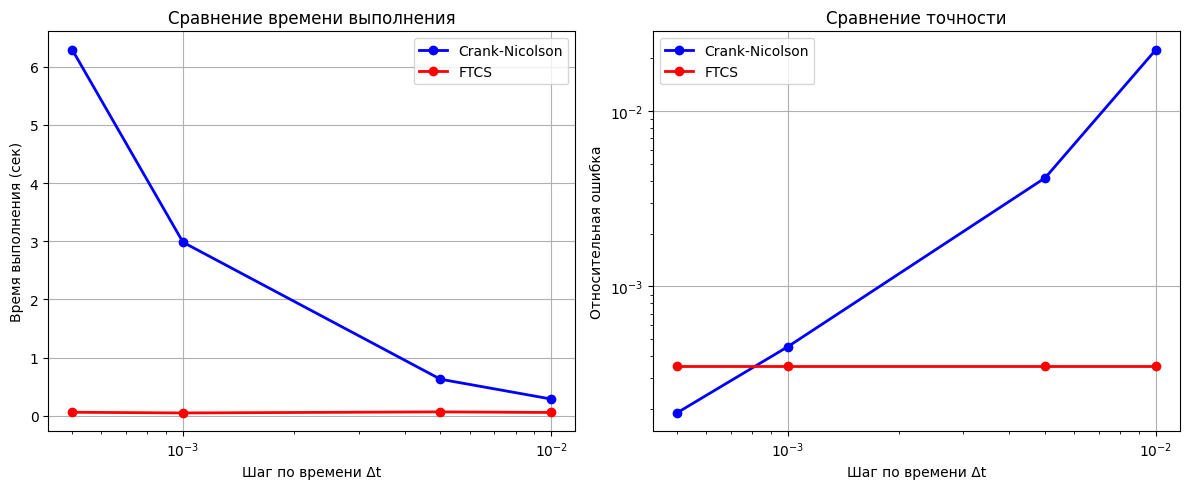

In [80]:
plot_comparison(dt_vals, ftcs_t, cn_t, ftcs_e, cn_e)

Параметрическое уравнение, описывающее форму сердца в декартовых координатах: 
$$
(x^{2} + y^{2} - 1)^{3} - x^{2}y^{3} <= 0
$$

In [81]:
def heart_shape_mask(Nx, Ny, Lx=2.0, Ly=2.0, center_x=1.0, center_y=1.0):
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y)
    x_norm = X - center_x
    y_norm = Y - center_y
    heart_mask = (x_norm**2 + y_norm**2 - 1)**3 - x_norm**2 * y_norm**3 <= 0
    return X, Y, heart_mask

In [82]:
def solve_heart_temperature():
    Nx, Ny = 100, 100
    t_end = 0.5
    source_temp = 100.0
    
    def k_func(X, Y):
        return np.ones_like(X)

    X, Y, heart_mask = heart_shape_mask(Nx, Ny, Lx=2.5, Ly=2.5, center_x=1.25, center_y=1.25)
    
    heart_indices = np.where(heart_mask)
    if len(heart_indices[0]) > 0:
        min_i, max_i = np.min(heart_indices[0]), np.max(heart_indices[0])
        min_j, max_j = np.min(heart_indices[1]), np.max(heart_indices[1])
        center_i = (min_i + max_i) // 2
        center_j = (min_j + max_j) // 2
        center_distance = np.inf
        best_i, best_j = center_i, center_j
        for i in range(min_i, max_i + 1):
            for j in range(min_j, max_j + 1):
                if heart_mask[i, j]:
                    dist_to_center = np.sqrt((i - center_i)**2 + (j - center_j)**2)
                    if dist_to_center < center_distance:
                        center_distance = dist_to_center
                        best_i, best_j = i, j
        center_i, center_j = best_i, best_j
        print(f"Центр сердца: индекс ({center_i}, {center_j}), координаты ({X[center_i, center_j]:.3f}, {Y[center_i, center_j]:.3f})")

    def ftcs_heart_solver(Nx, Ny, t_end, k_func, source_temp, heart_mask, center_i, center_j):
        Lx, Ly = 2.5, 2.5
        x = np.linspace(0, Lx, Nx)
        y = np.linspace(0, Ly, Ny)
        X, Y = np.meshgrid(x, y)
        dx = x[1] - x[0]
        dy = y[1] - y[0]
        dt = min(dx**2 / 4, dy**2 / 4) * 0.9
        Nt = int(t_end / dt) + 1

        u_initial = np.zeros((Ny, Nx))
        u_initial[center_i, center_j] = source_temp
        u = u_initial.copy()
        
        for n in range(Nt):
            u_old = u.copy()
            u_new = u_old.copy()
            for i in range(1, Ny-1):
                for j in range(1, Nx-1):
                    if heart_mask[i, j]:
                        k = k_func(X[i, j], Y[i, j])
                        alpha_x = k * dt / dx**2
                        alpha_y = k * dt / dy**2
                        left = u_old[i, j-1] if heart_mask[i, j-1] else u_old[i, j]
                        right = u_old[i, j+1] if heart_mask[i, j+1] else u_old[i, j]
                        top = u_old[i-1, j] if heart_mask[i-1, j] else u_old[i, j]
                        bottom = u_old[i+1, j] if heart_mask[i+1, j] else u_old[i, j]
                        u_new[i, j] = u_old[i, j] + alpha_x * (right - 2*u_old[i, j] + left) + alpha_y * (bottom - 2*u_old[i, j] + top)
            u_new[center_i, center_j] = source_temp
            u = u_new
        
        return X, Y, u_initial, u, k_func(X, Y), dt, Nt
    
    def cn_heart_solver(Nx, Ny, t_end, k_func, source_temp, heart_mask, center_i, center_j, dt=0.001):
        Lx, Ly = 2.5, 2.5
        x = np.linspace(0, Lx, Nx)
        y = np.linspace(0, Ly, Ny)
        X, Y = np.meshgrid(x, y)
        dx = x[1] - x[0]
        dy = y[1] - y[0]
        Nt = int(t_end / dt) + 1

        u_initial = np.zeros((Ny, Nx))
        u_initial[center_i, center_j] = source_temp
        u = u_initial.copy()

        for n in range(Nt):
            u_old = u.copy()
            u_new = u_old.copy()
            for iteration in range(2):
                for i in range(1, Ny-1):
                    for j in range(1, Nx-1):
                        if heart_mask[i, j]:
                            k = k_func(X[i, j], Y[i, j])
                            alpha_x = k * dt / (2 * dx**2)
                            alpha_y = k * dt / (2 * dy**2)
                            left = u_new[i, j-1] if heart_mask[i, j-1] else u_new[i, j]
                            right = u_new[i, j+1] if heart_mask[i, j+1] else u_new[i, j]
                            top = u_new[i-1, j] if heart_mask[i-1, j] else u_new[i, j]
                            bottom = u_new[i+1, j] if heart_mask[i+1, j] else u_new[i, j]
                            left_old = u_old[i, j-1] if heart_mask[i, j-1] else u_old[i, j]
                            right_old = u_old[i, j+1] if heart_mask[i, j+1] else u_old[i, j]
                            top_old = u_old[i-1, j] if heart_mask[i-1, j] else u_old[i, j]
                            bottom_old = u_old[i+1, j] if heart_mask[i+1, j] else u_old[i, j]
                            explicit = alpha_x * (right_old - 2*u_old[i, j] + left_old) + alpha_y * (bottom_old - 2*u_old[i, j] + top_old)
                            implicit = alpha_x * (right - 2*u_new[i, j] + left) + alpha_y * (bottom - 2*u_new[i, j] + top)
                            u_new[i, j] = u_old[i, j] + explicit + implicit
            u_new[center_i, center_j] = source_temp
            u = u_new
        
        return X, Y, u_initial, u, k_func(X, Y), dt, Nt

    X_ftcs, Y_ftcs, u_initial_ftcs, u_final_ftcs, k_ftcs, dt_ftcs, Nt_ftcs = ftcs_heart_solver(Nx, Ny, t_end, k_func, source_temp, heart_mask, center_i, center_j)
    X_cn, Y_cn, u_initial_cn, u_final_cn, k_cn, dt_cn, Nt_cn = cn_heart_solver(Nx, Ny, t_end, k_func, source_temp, heart_mask, center_i, center_j, dt=0.0001)
    
    return X_ftcs, Y_ftcs, u_final_ftcs, X_cn, Y_cn, u_final_cn, heart_mask, (center_i, center_j)

In [83]:
def plot_heart_comparison(X_ftcs, Y_ftcs, u_ftcs, X_cn, Y_cn, u_cn, heart_mask, center_coords):
    center_i, center_j = center_coords
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.delaxes(axes[1, 1])
    
    im1 = axes[0, 0].contourf(X_ftcs, Y_ftcs, heart_mask.astype(float), levels=1, cmap='Reds', alpha=0.7)
    axes[0, 0].contour(X_ftcs, Y_ftcs, heart_mask, levels=1, colors='red', linewidths=2)
    axes[0, 0].plot(X_ftcs[center_i, center_j], Y_ftcs[center_i, center_j], 'bo', markersize=8, label='Источник')
    axes[0, 0].set_title('Геометрия сердца с источником')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('y')
    axes[0, 0].set_aspect('equal')
    axes[0, 0].set_xlim(0, 2.5)
    axes[0, 0].set_ylim(0, 2.5)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    u_ftcs_heart = np.where(heart_mask, u_ftcs, np.nan)
    im3 = axes[0, 1].contourf(X_ftcs, Y_ftcs, u_ftcs_heart, levels=50, cmap='hot')
    axes[0, 1].contour(X_ftcs, Y_ftcs, heart_mask, levels=1, colors='white', linewidths=1, alpha=0.5)
    axes[0, 1].plot(X_ftcs[center_i, center_j], Y_ftcs[center_i, center_j], 'bo', markersize=6)
    axes[0, 1].set_title('FTCS: Температура в сердце')
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('y')
    axes[0, 1].set_aspect('equal')
    axes[0, 1].set_xlim(0, 2.5)
    axes[0, 1].set_ylim(0, 2.5)
    plt.colorbar(im3, ax=axes[0, 1], label='Температура')
    
    u_cn_heart = np.where(heart_mask, u_cn, np.nan)
    im6 = axes[1, 0].contourf(X_cn, Y_cn, u_cn_heart, levels=50, cmap='hot')
    axes[1, 0].contour(X_cn, Y_cn, heart_mask, levels=1, colors='white', linewidths=1, alpha=0.5)
    axes[1, 0].plot(X_cn[center_i, center_j], Y_cn[center_i, center_j], 'bo', markersize=6)
    axes[1, 0].set_title('Crank-Nicolson: Температура в сердце')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')
    axes[1, 0].set_aspect('equal')
    axes[1, 0].set_xlim(0, 2.5)
    axes[1, 0].set_ylim(0, 2.5)
    plt.colorbar(im6, ax=axes[1, 0], label='Температура')
    
    plt.tight_layout()
    plt.show()

In [84]:
X_ftcs, Y_ftcs, u_ftcs, X_cn, Y_cn, u_cn, heart_mask, center_coords = solve_heart_temperature()
plot_heart_comparison(X_ftcs, Y_ftcs, u_ftcs, X_cn, Y_cn, u_cn, heart_mask, center_coords)

Центр сердца: индекс (54, 49), координаты (1.237, 1.364)


KeyboardInterrupt: 